# Exploratory Data Analysis - part 2

## Variable types
There are different types of variables and the types must be examined in different ways. The four main types of data we will work with this semester are: 

1) Numeric 
2) Categorical 
3) Boolean 
4) String 

The usual summary statistics (mean, median, standard deviation) are useful for numeric variables, but they won't work well for the other categories. We will focus on how to find and summarize categorical and boolean variables in this workbook, with a short review of numeric data. 



## Import data and explore data set 
Use the auto2.dta dataset to learn more about exploring data. This dataset is in stata format. We'll need to download it from the stata website. Go to this [URL](https://www.stata-press.com/data/r14/d.html) and find the auto2.dta file. Save it somewhere you can find it. Put the path to your file in the read_stata command in the second cell below. 

There are two ways to specify the path:
1. Save the auto2.dta file in the same folder as your Jupyter notebook. If you do that you do not have specify the path:   df = pd.read_csv('students.csv')
2. Specify the full path: \
On PC: \
df = pd.read_csv('C:/Users/YourName/Downloads/students.csv') \
On Mac/Linux: \
df = pd.read_csv('/home/username/Downloads/students.csv') 

If you need to see where Jupyter is looking for files, you can checking your working directory: 
print(os.getcwd())  # Shows where Python is looking for files



In [3]:
## Import packages

import pandas as pd               # Data management
import seaborn as sns             # Data visualizaiton 
import matplotlib.pyplot as plt   # Display plots in the notebook

import os
print(os.getcwd())          # Shows where Python is looking for files

/Users/Scott/Econ 300 - Spring 2025


In [4]:
# The cars data set is available in pandas, so we can move it directly to a dataframe. 

df = pd.read_stata("/Users/Scott/Downloads/auto2.dta")
df.head()


,make,price,mpg,rep78,headroom,trunk,weight,length,turn,displacement,gear_ratio,foreign
0,AMC Concord,4099,22,Average,2.5,11,2930,186,40,121,3.58,Domestic
1,AMC Pacer,4749,17,Average,3.0,11,3350,173,40,258,2.53,Domestic
2,AMC Spirit,3799,22,NaN,3.0,12,2640,168,35,121,3.08,Domestic
3,Buick Century,4816,20,Average,4.5,16,3250,196,40,196,2.93,Domestic
4,Buick Electra,7827,15,Good,4.0,20,4080,222,43,350,2.41,Domestic


In [5]:
# Visually inspect the raw data
print(df)                              # Prints the entire datset to the terminal
print(df.head(10))                     # Prints the first ten rows
df.tail()                              # Prints the final five rows by default

             make  price  mpg      rep78  headroom  trunk  weight  length  \
0     AMC Concord   4099   22    Average       2.5     11    2930     186   
1       AMC Pacer   4749   17    Average       3.0     11    3350     173   
2      AMC Spirit   3799   22        NaN       3.0     12    2640     168   
3   Buick Century   4816   20    Average       4.5     16    3250     196   
4   Buick Electra   7827   15       Good       4.0     20    4080     222   
..            ...    ...  ...        ...       ...    ...     ...     ...   
69      VW Dasher   7140   23       Good       2.5     12    2160     172   
70      VW Diesel   5397   41  Excellent       3.0     15    2040     155   
71      VW Rabbit   4697   25       Good       3.0     15    1930     155   
72    VW Scirocco   6850   25       Good       2.0     16    1990     156   
73      Volvo 260  11995   17  Excellent       2.5     14    3170     193   

    turn  displacement  gear_ratio   foreign  
0     40           121      

,make,price,mpg,rep78,headroom,trunk,weight,length,turn,displacement,gear_ratio,foreign
69,VW Dasher,7140,23,Good,2.5,12,2160,172,36,97,3.74,Foreign
70,VW Diesel,5397,41,Excellent,3.0,15,2040,155,35,90,3.78,Foreign
71,VW Rabbit,4697,25,Good,3.0,15,1930,155,35,89,3.78,Foreign
72,VW Scirocco,6850,25,Good,2.0,16,1990,156,36,97,3.78,Foreign
73,Volvo 260,11995,17,Excellent,2.5,14,3170,193,37,163,2.98,Foreign


In [6]:
# Find the datatype for every variable:
print(df.dtypes)

# Find the dimensions of the data set:
print(df.shape)

# Get a missing data report: 
print(df.isnull().sum())

make              object
price              int16
mpg                int16
rep78           category
headroom         float32
trunk              int16
weight             int16
length             int16
turn               int16
displacement       int16
gear_ratio       float32
foreign         category
dtype: object
(74, 12)
make            0
price           0
mpg             0
rep78           5
headroom        0
trunk           0
weight          0
length          0
turn            0
displacement    0
gear_ratio      0
foreign         0
dtype: int64


rep78
Average      30
Good         18
Excellent    11
Fair          8
Poor          2
Name: count, dtype: int64


/Users/Scott/opt/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/Scott/opt/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/Scott/opt/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/Scott/opt/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is

,make,price,mpg,headroom,trunk,weight,length,turn,displacement,gear_ratio,foreign,rep78_Poor,rep78_Fair,rep78_Average,rep78_Good,rep78_Excellent
0,AMC Concord,4099,22,2.5,11,2930,186,40,121,3.58,Domestic,False,False,True,False,False
1,AMC Pacer,4749,17,3.0,11,3350,173,40,258,2.53,Domestic,False,False,True,False,False
2,AMC Spirit,3799,22,3.0,12,2640,168,35,121,3.08,Domestic,False,False,False,False,False
3,Buick Century,4816,20,4.5,16,3250,196,40,196,2.93,Domestic,False,False,True,False,False
4,Buick Electra,7827,15,4.0,20,4080,222,43,350,2.41,Domestic,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69,VW Dasher,7140,23,2.5,12,2160,172,36,97,3.74,Foreign,False,False,False,True,False
70,VW Diesel,5397,41,3.0,15,2040,155,35,90,3.78,Foreign,False,False,False,False,True
71,VW Rabbit,4697,25,3.0,15,1930,155,35,89,3.78,Foreign,False,False,False,True,False
72,VW Scirocco,6850,25,2.0,16,1990,156,36,97,3.78,Foreign,False,False,False,True,False


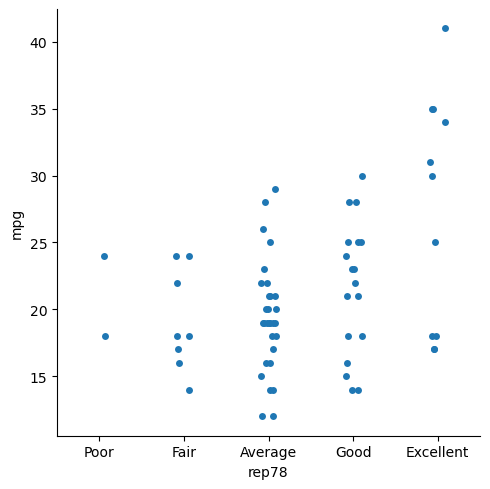

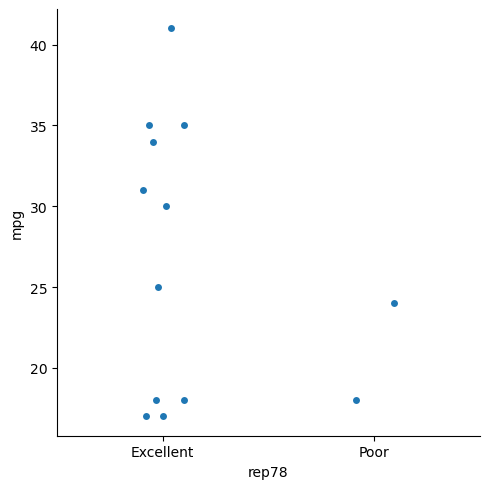

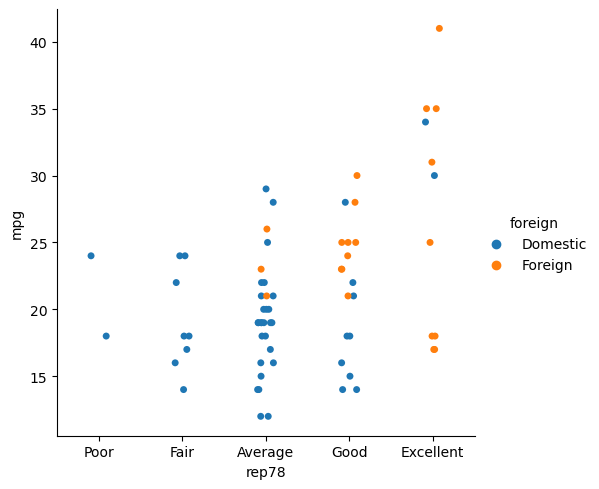

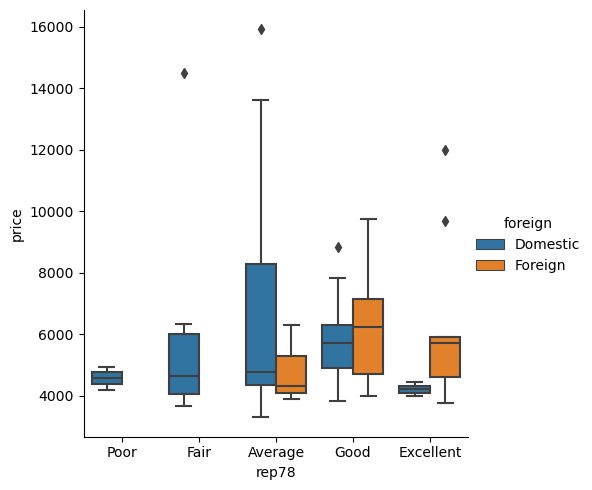

In [7]:
# Explore categorical values

print(df["rep78"].value_counts())

# Print a scatter plot of miles per gallon against repair rating 
sns.catplot(data=df, x="rep78", y="mpg")
sns.catplot(data=df, x="rep78", y="mpg", order=["Excellent", "Poor"])   # Limit the values displayed
sns.catplot(data=df, x="rep78", y="mpg", hue="foreign")                 # Color by a 3rd variable 
sns.catplot(data=df, x="rep78", y="price", hue="foreign", kind="box")   # Provide distribution info via box plot

# Add dummy variables for the repair reputation
pd.get_dummies(df, columns=["rep78"])



              price        mpg   headroom      trunk       weight      length  \
count     74.000000  74.000000  74.000000  74.000000    74.000000   74.000000   
mean    6165.256757  21.297297   2.993243  13.756757  3019.459459  187.932432   
std     2949.495885   5.785503   0.845995   4.277404   777.193567   22.266340   
min     3291.000000  12.000000   1.500000   5.000000  1760.000000  142.000000   
25%     4220.250000  18.000000   2.500000  10.250000  2250.000000  170.000000   
50%     5006.500000  20.000000   3.000000  14.000000  3190.000000  192.500000   
75%     6332.250000  24.750000   3.500000  16.750000  3600.000000  203.750000   
max    15906.000000  41.000000   5.000000  23.000000  4840.000000  233.000000   

            turn  displacement  gear_ratio  
count  74.000000     74.000000   74.000000  
mean   39.648649    197.297297    3.014865  
std     4.399354     91.837219    0.456287  
min    31.000000     79.000000    2.190000  
25%    36.000000    119.000000    2.730000  


<Axes: xlabel='weight'>

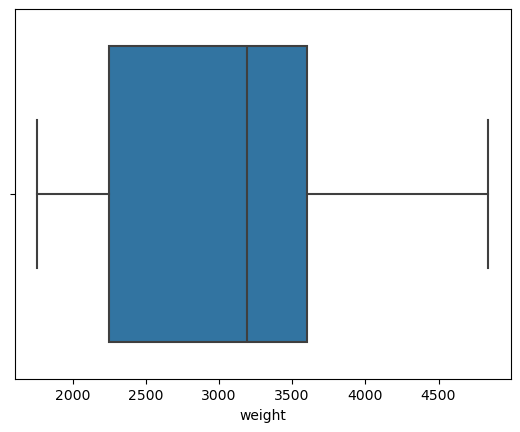

In [8]:
# Explore numeric data 

# Summary statistics 
print(df.describe())


# Graph the distribution of a single variable
sns.boxplot(x=df['weight'])



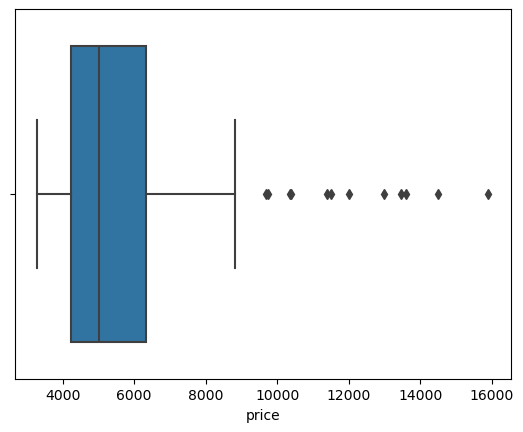

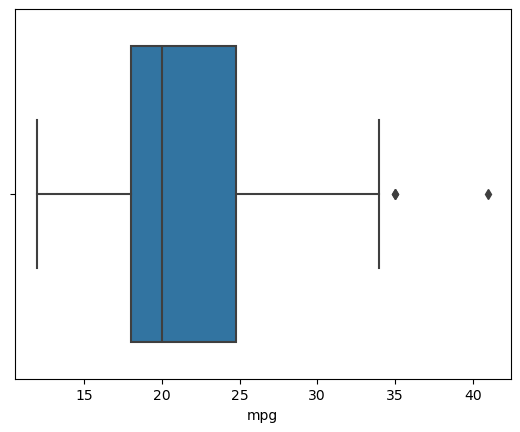

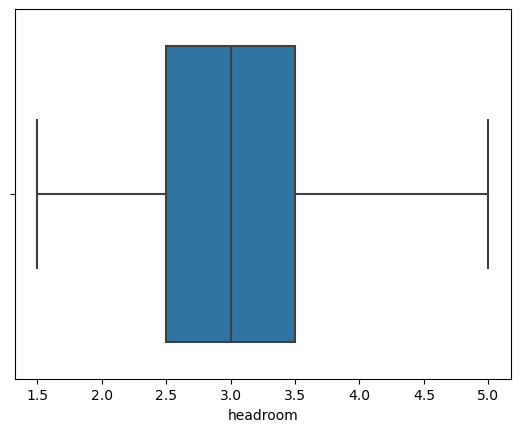

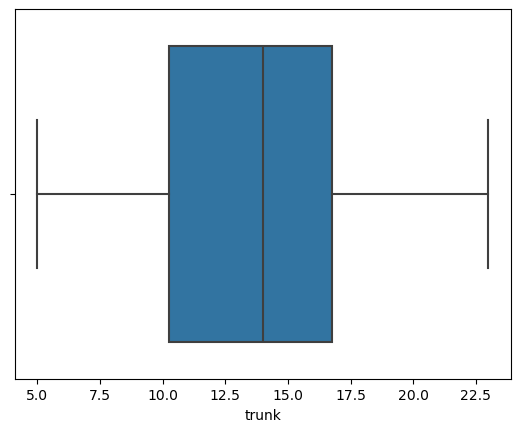

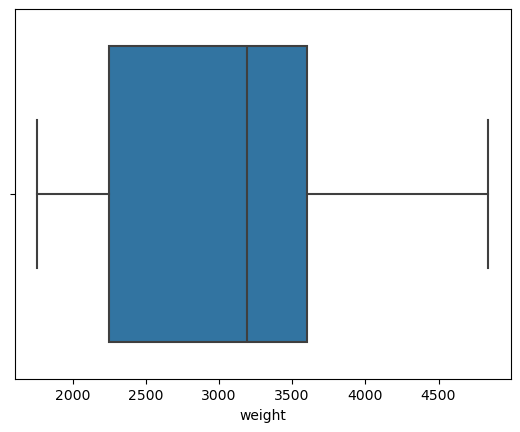

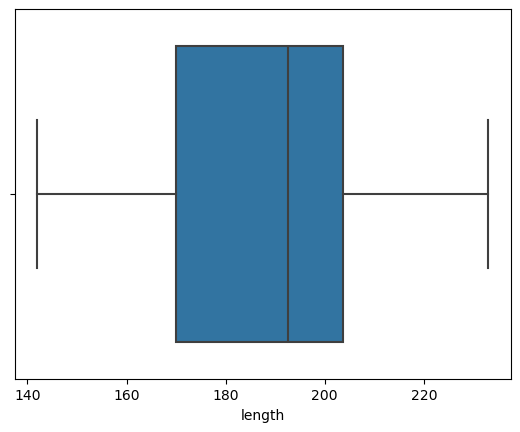

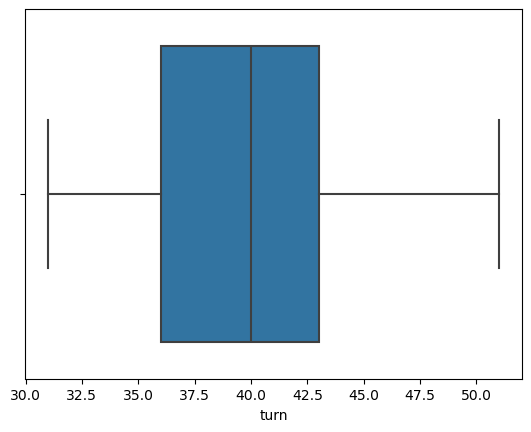

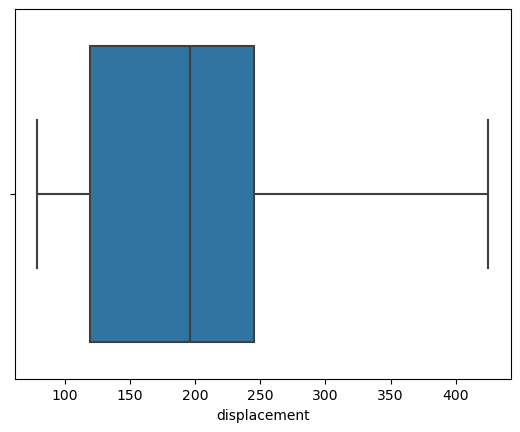

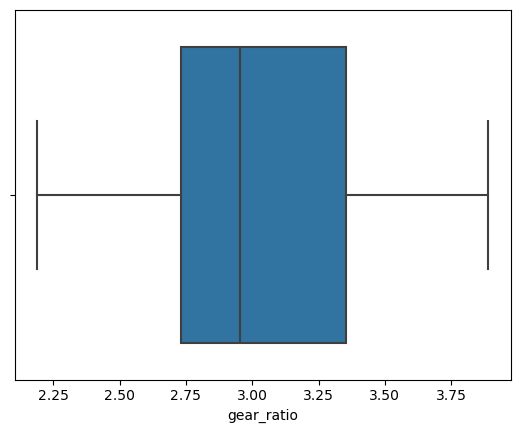

In [9]:
# We can write a loop that produces a box plot for each numeric variable in the auto's data set.  

num_var=['price', 'mpg', 'headroom', 'trunk', 'weight', 'length', 'turn', 'displacement', 'gear_ratio']

for var in num_var:
    sns.boxplot(x=df[var])
    plt.show()